<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
Rule Mining
</h1>

# 🍿 Discovering Movie Patterns with Apriori

In this notebook, we use **association rule mining** to discover interesting relationships in movies.  
Our goal is to uncover frequent combinations of movie attributes — such as genres, languages and other key factors — that often appear together.

This serves as a **pre-step** toward building a more intelligent and personalized **movie recommendation system**.

---

### 🔍 Why Apriori?

The **Apriori algorithm** is a classic and interpretable method for discovering patterns in transactional datasets.  
In our case, each *movie* is treated like a *transaction* containing various attributes (e.g., "Action", "English", "Belongs To Collection").

It helps us answer questions like:
- *Which genres often appear together?*
- *If a movie is sci-fi, how likely is it to also be part of a collection?*

In [724]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

## 🧭 Step 1: Define What We Want to Discover

Before diving into the Apriori algorithm, it's important to define the **questions or themes** we want to explore.  
Association rule mining is most useful when we’re curious about patterns such as:

- 🎥 *Which genres frequently appear together?*
- 🧑‍🤝‍🧑 *Do movies that release in a certain season generate more revenue?*
- 🌍 *Is there a connection between a movie’s language and its popularity level?*
- 💸 *Do high-budget movies tend to belong to collections or have taglines?*

These questions help us determine which features are relevant and how we need to preprocess them.

---

## 🔍 Step 2: Identify Features Already in Binary Format

Because **Apriori requires boolean (0/1) features**, we begin by identifying features that are already in a usable format.

Our dataset already includes several binary columns such as:
- `belongs_to_collection`
- `has_tagline`
- `has_homepage`
- `changed_title`
- `top10_prod_comps`
- `is_english_spoken`
- Genre indicators (e.g., `Action`, `Drama`, `Comedy`, etc.)

These are **ready to be fed directly into Apriori**.

---

## 🔧 Step 3: Transform Other Features (If Needed)

Based on the questions we defined, we may want to include additional features that aren’t already binary.  
For those, we need to preprocess them in one of two ways:

### Categorical Features → One-Hot Encoding
Examples:
- `main_production_country`
- `season`

We can convert the most common categories into separate binary columns (e.g., `country_USA`, `season_Summer`).

### Numeric Features → Binning → One-Hot Encoding
Examples:
- `runtime`, `budget`, `revenue`, `vote_average`, `profit_or_loss`

We'll first divide these into meaningful ranges (like short/medium/long or low/medium/high), then convert those into binary columns.

This transformation ensures we’re representing **interpretable conditions** (e.g., “High Budget” or “Popular Movie”) in a format Apriori understands.

---

By tailoring our feature selection and transformation to our questions, we ensure the resulting association rules are both valid and valuable.


In [725]:
df = pd.read_csv('tmdb_movies_cleaned.csv')

### 🎯 Choosing the Right Questions for Recommendation

Since our goal is to build a **recommendation system**, we focus on exploring rules that reflect **user preferences and content relationships** — not internal production or marketing metrics.

That means we'll prioritize **consumer-relevant patterns** and avoid less actionable insights tied to budget, revenue, or studio logistics.

Here are the key questions we’ll explore:

1. 🎭 **Genre Combinations**  
   Which genres frequently appear together, and how can this guide multi-genre recommendations?

2. 📦 **Belongs to Collection → Weighted Rating**  
   Do movies that are part of a franchise or collection tend to be rated higher?

3. ⏱️ **Movie Length → Decade Targeting**  
   Are certain movie lengths more common in specific eras?

4. 🌍 **Language → Popularity**  
   Does being English-speaking increase a movie's likelihood of being popular?

These focused explorations will help us generate **actionable rules** that enhance the intelligence and relevance of our future recommender.
___


## 🎭 Question 1: Genre Combinations

Which genres tend to appear together in movies?

Since each genre (e.g., `Action`, `Drama`, `Comedy`) is already in binary format, we can directly apply **Apriori** to uncover frequent genre pairs or groups.

We'll extract:
- Common genre itemsets
- Rules like: *If a movie is Sci-Fi, how often is it also Thriller?*

This helps us understand genre trends and can support genre-based recommendations later.


In [726]:
df.columns

Index(['id', 'title', 'runtime', 'release_date', 'budget', 'revenue',
       'popularity', 'vote_average', 'vote_count', 'belongs_to_collection',
       'has_tagline', 'has_homepage', 'num_same_title', 'changed_title',
       'num_genres', 'Comedy', 'Action', 'Animation', 'Drama', 'History',
       'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy',
       'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance',
       'Mystery', 'Horror', 'top10_prod_comps', 'num_production_companies',
       'main_production_country', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'season',
       'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

In [727]:
genres_df = df[['Comedy', 'Action', 'Animation', 'Drama', 'History',
       'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy',
       'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance',
       'Mystery', 'Horror']]

In [728]:
print(genres_df.shape)
print(genres_df.columns)

(9953, 19)
Index(['Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War',
       'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction',
       'TV Movie', 'Western', 'Documentary', 'Romance', 'Mystery', 'Horror'],
      dtype='object')


### 📊 Apriori Core Concepts

To interpret the rules Apriori generates, we rely on three key metrics:

- **Support - P(A ^ B)**:  
  How frequently an itemset appears in the dataset.  
  > *E.g., 20% of movies are tagged as both "Action" and "Adventure" → support = 0.20*

- **Confidence - P(B | A)**:  
  How often the rule is true.  
  > *If 70% of movies with a homepage also include “Sci-Fi”, then confidence = 0.70*

- **Lift - Confidence / P(B)**:  
  How much more likely two items co-occur than if they were independent.  
  > *Lift = 1 means no association - A and B are likely independent*  
  > *Lift > 1 implies a meaningful connection - A increases the likelihood of B*  
  > *Lift < 1 implies a negative connection - A reduces the likelihood of B*  

**Parameters**:

- *min_support*: Minimum frequency threshold for itemsets to be considered.
- *min_support*: Minimum strength of the association rules. Minimum strength of the association rules.

In [729]:
frequent_itemsets1 = apriori(genres_df, min_support=0.1, use_colnames=True)

print("Frequent Movie Genres Discovered:")
print(frequent_itemsets1.sort_values(by='support', ascending=False))

Frequent Movie Genres Discovered:
     support           itemsets
2   0.485482            (Drama)
0   0.369939           (Comedy)
4   0.240430         (Thriller)
1   0.231890           (Action)
7   0.203155          (Romance)
6   0.169095        (Adventure)
5   0.157641            (Crime)
12  0.130011   (Romance, Drama)
9   0.120868    (Comedy, Drama)
8   0.111323           (Horror)
10  0.104692  (Romance, Comedy)
11  0.102281  (Thriller, Drama)
3   0.100573           (Family)


In [730]:
rules1 = association_rules(frequent_itemsets1, metric="confidence", min_threshold=0.1)

print("Association Rules Discovered:")
print(rules1[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules Discovered:
  antecedents consequents   support  confidence      lift
0    (Comedy)     (Drama)  0.120868    0.326725  0.672990
1     (Drama)    (Comedy)  0.120868    0.248965  0.672990
2   (Romance)    (Comedy)  0.104692    0.515331  1.393018
3    (Comedy)   (Romance)  0.104692    0.282998  1.393018
4  (Thriller)     (Drama)  0.102281    0.425407  0.876258
5     (Drama)  (Thriller)  0.102281    0.210679  0.876258
6   (Romance)     (Drama)  0.130011    0.639960  1.318197
7     (Drama)   (Romance)  0.130011    0.267798  1.318197


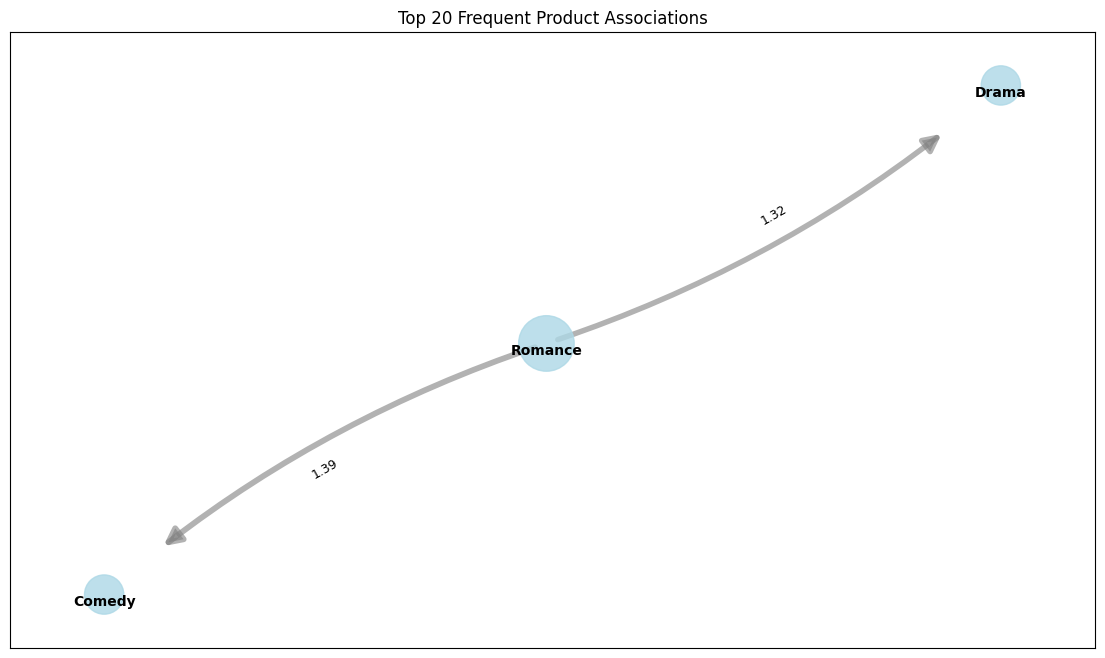

In [731]:
plot_association_graph(rules1, min_confidence=0.5, min_lift=0.8)

#### 🤔 Understanding the metrics for `Romance` -> `Drama`:
* The highest **combination** of movie genres, at about 13% of all movies, is `Romance-Drama`.  
* The likelihood of a `Romance` movie being also a `Drama` movie is around 64%.  
* `Romance` and `Drama` are more often together then independently by about 32%.  

Conclusion: If you're watching a `Romance` movie, you're significantly more likely to also be watching a `Drama`, compared to picking genres at random.  

#### 📈 Deeper Implications of the `Romance` → `Drama` Rule

Beyond the basic lift and confidence values, this association rule between `Romance` and `Drama` reveals several useful insights:

- 🌀 **Genre Blending Insight**:  
  The frequent co-occurrence suggests that `Romance` and `Drama` are often intentionally blended in storytelling to create emotionally engaging narratives.

- 🎯 **Audience Preferences**:  
  Users who enjoy `Romance` are statistically more likely to also enjoy or tolerate `Drama`. This can help personalize recommendations even if a user only selects `Romance`.

- 🎭 **Labeling and Expectation Setting**:  
  With 64% of Romance movies also tagged as Drama, "pure" Romance films are relatively rare. This helps manage user expectations — most Romance films will likely include serious or emotional storylines.

- 🔁 **Asymmetry Matters**:  
  The rule is directional: while most Romance films are also Drama, not all Drama films are Romance. This asymmetry is important when building logic for recommendations or genre-based filters.

- 🤖 **Recommendation Engine Tip**:  
  You can use this rule in your content-based recommender system by increasing the weight of `Drama` for users who show a preference for `Romance`, even without them explicitly stating it.

___

## 📦 Question 2: Collections and Ratings

Do movies that belong to a collection tend to receive higher ratings?

By analyzing the binary feature `belongs_to_collection` alongside `weighted_rating` (after binning it into categories), we can use **Apriori** to discover if being part of a franchise correlates with higher audience approval.

We'll extract:
- Rules like: *If a movie belongs to a collection, how likely is it to be highly rated?*

This can help us understand whether franchise association is a quality signal in recommendations.


In [732]:
print(f"The minimum value for weighted rating is: {df['weighted_rating'].min().round(2)} and the maximum value is: {df['weighted_rating'].max().round(2)}")

The minimum value for weighted rating is: 3.06 and the maximum value is: 8.7


In [733]:
# Check for null values in 'weighted_rating'
df['weighted_rating'].isnull().any()

np.False_

In [734]:
df['belongs_to_collection'] = df['belongs_to_collection'].astype(bool)

In [735]:
# Define the bins and labels
bins = [3, 4, 5, 6, 7, 8, 9]
labels = ['3-4', '4-5', '5-6', '6-7', '7-8', '8-9']

df['binned_rating'] = pd.cut(df['weighted_rating'], bins=bins, labels=labels, include_lowest=False)

In [736]:
df[['weighted_rating', 'binned_rating']]

,weighted_rating,binned_rating
0,5.915191,5-6
1,6.430314,6-7
2,8.194340,8-9
3,7.808617,7-8
4,8.460581,8-9
...,...,...
9948,5.821839,5-6
9949,6.250978,6-7
9950,6.092949,6-7
9951,6.179887,6-7


In [737]:
q2_df = df[['belongs_to_collection', 'binned_rating']].copy()

In [738]:
q2_df = pd.get_dummies(q2_df, columns=['binned_rating'])

In [739]:
q2_df

,belongs_to_collection,binned_rating_3-4,binned_rating_4-5,binned_rating_5-6,binned_rating_6-7,binned_rating_7-8,binned_rating_8-9
0,False,False,False,True,False,False,False
1,False,False,False,False,True,False,False
2,True,False,False,False,False,False,True
3,True,False,False,False,False,True,False
4,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
9948,False,False,False,True,False,False,False
9949,True,False,False,False,True,False,False
9950,True,False,False,False,True,False,False
9951,False,False,False,False,True,False,False


In [740]:
frequent_itemsets2 = apriori(q2_df, min_support=0.1, use_colnames=True)

print("Frequent Itemsets for Binned Ratings and Collections:")
print(frequent_itemsets2.sort_values(by='support', ascending=False))

Frequent Itemsets for Binned Ratings and Collections:
    support                                    itemsets
2  0.627349                         (binned_rating_6-7)
0  0.220436                     (belongs_to_collection)
1  0.186175                         (binned_rating_5-6)
3  0.160956                         (binned_rating_7-8)
4  0.123480  (binned_rating_6-7, belongs_to_collection)


In [741]:
rules2 = association_rules(frequent_itemsets2, metric="confidence", min_threshold=0.1)

print("Association Rules Discovered:")
print(rules2[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules Discovered:
               antecedents              consequents  support  confidence  \
0      (binned_rating_6-7)  (belongs_to_collection)  0.12348    0.196829   
1  (belongs_to_collection)      (binned_rating_6-7)  0.12348    0.560164   

       lift  
0  0.892907  
1  0.892907  


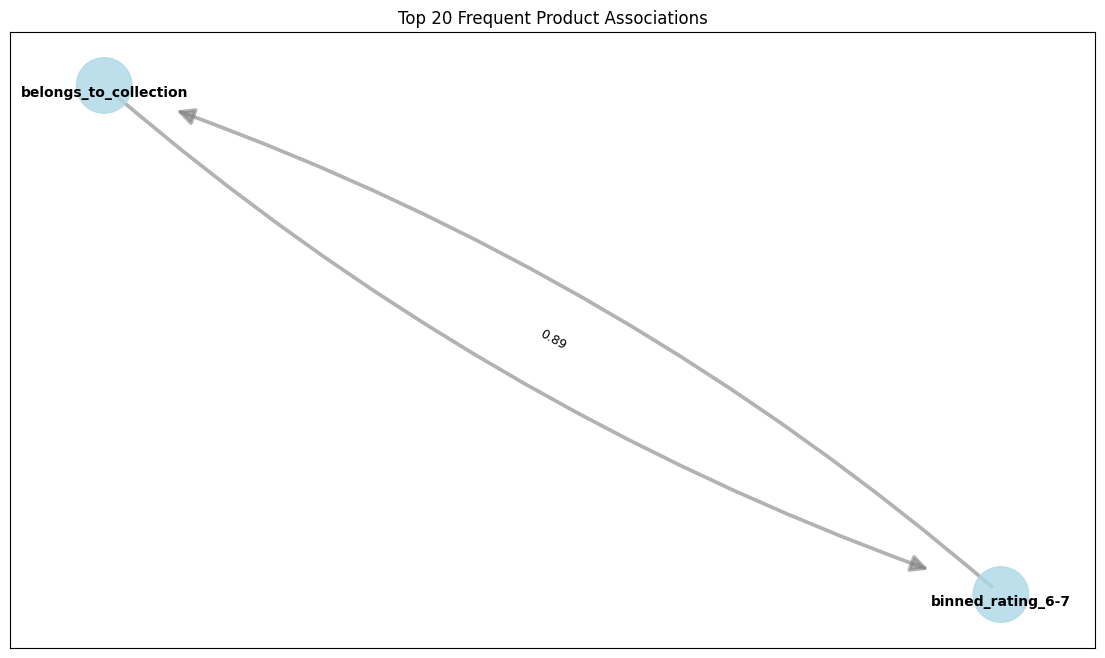

In [742]:
plot_association_graph(rules2, min_confidence=0.1, min_lift=0.8)

### 🤔 Do Collections Tend to Have Higher Ratings?
- `binned_rating_6-7` is the **most common rating group**, covering **62.7%** of all movies.
- `belongs_to_collection` applies to **22%** of movies.
- The combination of both — collection movies with a 6–7 rating — occurs in **12.3%** of the dataset.

### 🔄 Association Rule Results:
- **Rule**: `belongs_to_collection → binned_rating_6-7`
  - **Confidence**: 56%
  - **Lift**: 0.89 (i.e., 11% *less* likely than random)
  
- **Rule**: `binned_rating_6-7 → belongs_to_collection`
  - **Confidence**: 19.7%
  - **Lift**: 0.89

### 🎯 Conclusion:
Although over half of collection movies fall into the 6–7 rating group, this is mainly because that rating bin is **common overall** — not because collections are especially likely to score that way.

The **lift < 1** suggests that being in a collection does **not meaningfully increase** the chance of having a 6–7 rating.  
In fact, the pairing occurs **slightly less often than chance would predict**, implying **no strong positive association** between collections and mid-to-high ratings.

___

## ⏱️ Question 3: Movie Length and Decade Preference

Are certain movie lengths more typical of specific decades — and can that help guide time-based recommendations?

We'll categorize `runtime` into bins like `Short`, `Medium`, and `Long`, and explore associations with the `release_year` (grouped into decades).

We'll extract:
- Rules like: *If a user wants a short movie, suggest titles from the 2010s.*

This helps match user time constraints with appropriate eras in film history.


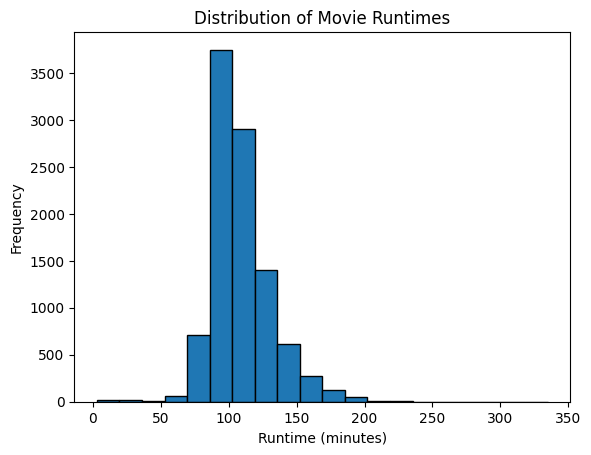

In [743]:
plt.hist(df['runtime'], bins=20, edgecolor='black')
plt.title("Distribution of Movie Runtimes")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.show()

In [744]:
# Define the bins and labels
bins = [0, 60, 90, 120, np.inf]
labels = ['Short(Under 60 Mins)', 'Medium(60-90 Mins)', 'Long(90-120 Mins)', 'Very Long(Over 120 Mins)']

df['binned_runtime'] = pd.cut(df['runtime'], bins=bins, labels=labels, include_lowest=False)

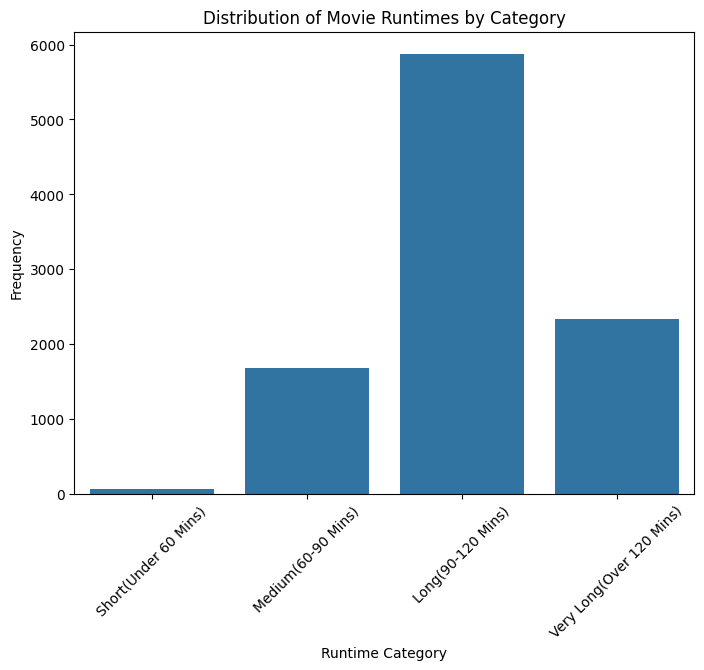

In [745]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='binned_runtime')
plt.title("Distribution of Movie Runtimes by Category")
plt.xticks(rotation=45)
plt.xlabel("Runtime Category")
plt.ylabel("Frequency")
plt.show()

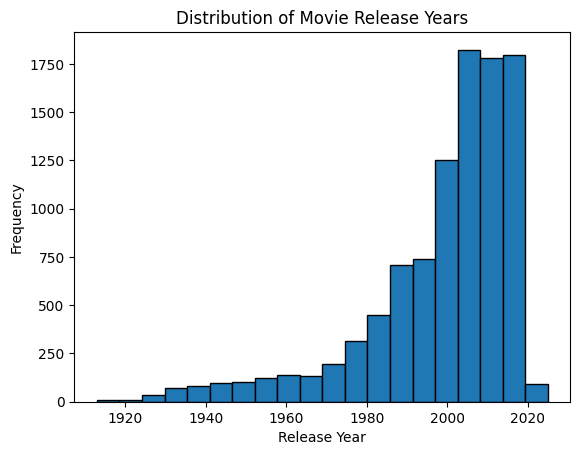

In [746]:
plt.hist(df['release_year'], bins=20, edgecolor='black')
plt.title("Distribution of Movie Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

In [747]:
print(f"The minimum release year is: {df['release_year'].min()} and the maximum is: {df['release_year'].max()}")

The minimum release year is: 1913 and the maximum is: 2025


In [748]:
# Define the bins and labels
bins = [0, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, np.inf]
labels = ['1910s', '1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

df['binned_release_year'] = pd.cut(df['release_year'], bins=bins, labels=labels, include_lowest=False)

In [749]:
df['binned_release_year']

0       1990s
1       1990s
2       1970s
3       2000s
4       1990s
        ...  
9948    2010s
9949    2010s
9950    2010s
9951    2010s
9952    2010s
Name: binned_release_year, Length: 9953, dtype: category
Categories (12, object): ['1910s' < '1920s' < '1930s' < '1940s' ... '1990s' < '2000s' < '2010s' < '2020s']

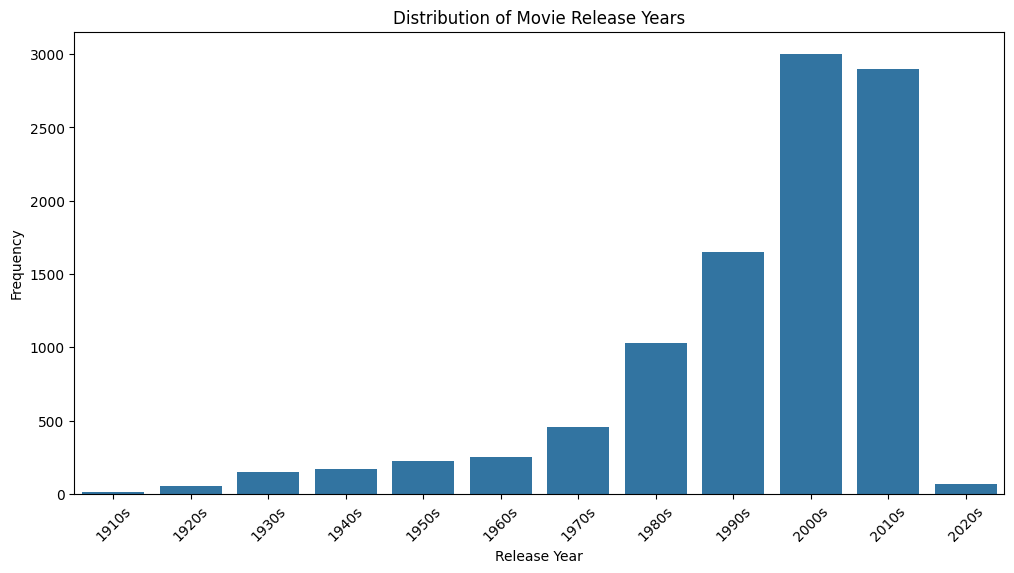

In [750]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='binned_release_year')
plt.title("Distribution of Movie Release Years")
plt.xticks(rotation=45)
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

In [751]:
q3_df = df[['binned_runtime', 'binned_release_year']].copy()

In [752]:
q3_df = pd.get_dummies(q3_df)

In [753]:
q3_df

,binned_runtime_Short(Under 60 Mins),binned_runtime_Medium(60-90 Mins),binned_runtime_Long(90-120 Mins),binned_runtime_Very Long(Over 120 Mins),binned_release_year_1910s,binned_release_year_1920s,binned_release_year_1930s,binned_release_year_1940s,binned_release_year_1950s,binned_release_year_1960s,binned_release_year_1970s,binned_release_year_1980s,binned_release_year_1990s,binned_release_year_2000s,binned_release_year_2010s,binned_release_year_2020s
0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9948,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
9949,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
9950,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
9951,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False


In [754]:
frequent_itemsets3 = apriori(q3_df, min_support=0.1, use_colnames=True)

print("Frequent Itemsets for Binned Runtimes and Release Years:")
print(frequent_itemsets3.sort_values(by='support', ascending=False))

Frequent Itemsets for Binned Runtimes and Release Years:
    support                                           itemsets
1  0.590777                 (binned_runtime_Long(90-120 Mins))
5  0.301718                        (binned_release_year_2000s)
6  0.291269                        (binned_release_year_2010s)
2  0.234904          (binned_runtime_Very Long(Over 120 Mins))
8  0.179343  (binned_runtime_Long(90-120 Mins), binned_rele...
0  0.168693                (binned_runtime_Medium(60-90 Mins))
9  0.167889  (binned_runtime_Long(90-120 Mins), binned_rele...
4  0.165679                        (binned_release_year_1990s)
3  0.103185                        (binned_release_year_1980s)
7  0.101376  (binned_runtime_Long(90-120 Mins), binned_rele...


In [755]:
rules3 = association_rules(frequent_itemsets3, metric="confidence", min_threshold=0.2)

print("Association Rules Discovered:")
print(rules3[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules Discovered:
                          antecedents                         consequents  \
0         (binned_release_year_1990s)  (binned_runtime_Long(90-120 Mins))   
1  (binned_runtime_Long(90-120 Mins))         (binned_release_year_2000s)   
2         (binned_release_year_2000s)  (binned_runtime_Long(90-120 Mins))   
3  (binned_runtime_Long(90-120 Mins))         (binned_release_year_2010s)   
4         (binned_release_year_2010s)  (binned_runtime_Long(90-120 Mins))   

    support  confidence      lift  
0  0.101376    0.611886  1.035732  
1  0.179343    0.303571  1.006143  
2  0.179343    0.594406  1.006143  
3  0.167889    0.284184  0.975674  
4  0.167889    0.576406  0.975674  


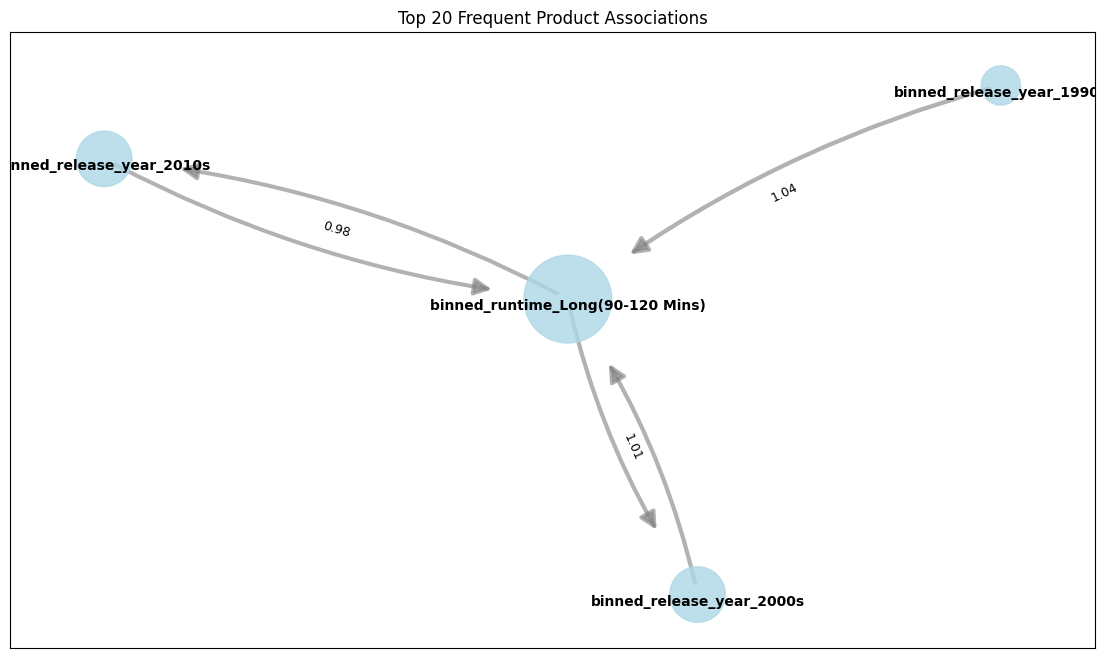

In [756]:
plot_association_graph(rules3, min_confidence=0.1, min_lift=0.95)

### 🤔 Runtime and Decade Preferences

Here's what we found:

### 1️⃣ 1990s Movies Tend to Be 90–120 Minutes Long  
- **Rule**: `1990s → 90–120 mins`  
- **Confidence**: 61.2%  
- **Lift**: 1.036  
📌 **Conclusion**: If you're looking for a movie from the 1990s, you're slightly more likely to find it in the common 90–120 minute range. While not a strong association, it's above random.


### 2️⃣ 2000s and Runtime: Mutual Weak Association  
- **Rule**: `90–120 mins → 2000s` → Confidence: 30%, Lift: ~1.006  
- **Rule**: `2000s → 90–120 mins` → Confidence: 59%, Lift: ~1.006  
📌 **Conclusion**: There's a **mild two-way association** between 2000s films and standard-length movies. The relationship exists in both directions, but the lift near 1.0 means it's **neutral and not particularly insightful** for recommendations.


### 3️⃣ 2010s and Runtime: Slight Negative Correlation  
- **Rule**: `90–120 mins → 2010s` → Confidence: 28%, Lift: ~0.976  
- **Rule**: `2010s → 90–120 mins` → Confidence: 58%, Lift: ~0.976  
📌 **Conclusion**: Although over half of 2010s movies are in the 90–120 min range, that’s mostly due to this runtime being common in general.  
   The **lift below 1.0** suggests that 2010s movies are **slightly less likely** to fall in this range than you'd expect by chance.



### 🎯 Conclusion:
While runtime distributions vary slightly by decade, the lift values (~1.0) indicate there's **no strong decade-based bias** for runtime categories.  
Still, minor trends can be useful: if a user wants a **90–120 min film**, looking into the 1990s or 2000s could slightly increase the odds.
____


## 🌍 Question 4: Language and Popularity

Does speaking English correlate with a higher chance of popularity?

Using the binary feature `is_english_spoken` and a binned version of `popularity`, we’ll explore how language impacts a movie’s reach.

We'll extract:
- Rules like: *If a movie is in English, how likely is it to fall into the top popularity tier?*

These insights can support language-aware recommendations, especially for international or multilingual users.


In [757]:
df['popularity'].describe()

count    9953.000000
mean        4.518899
std         7.265972
min         0.012500
25%         1.533100
50%         2.958000
75%         5.312600
max       390.447100
Name: popularity, dtype: float64

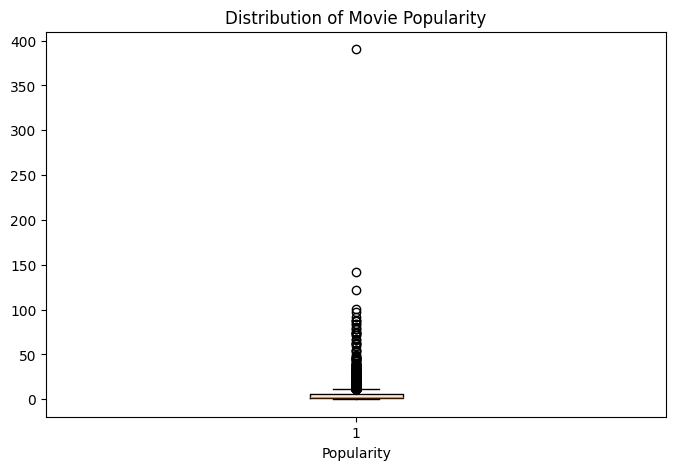

In [758]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['popularity'])
plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.show()

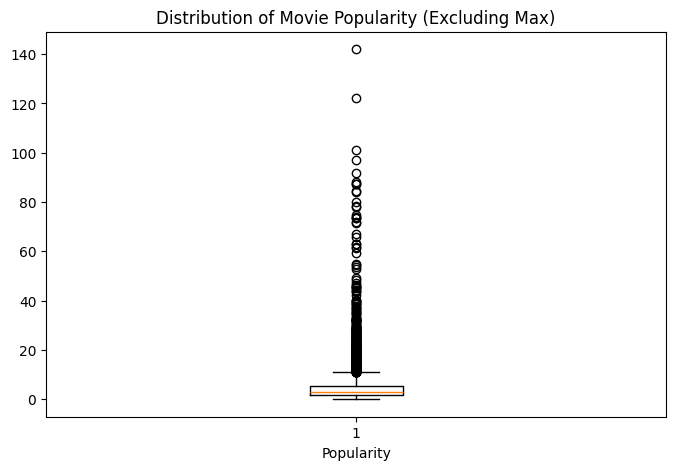

In [759]:
popularity_trimmed = df['popularity'][df['popularity'] < df['popularity'].max()]

plt.figure(figsize=(8, 5))
plt.boxplot(popularity_trimmed)
plt.title("Distribution of Movie Popularity (Excluding Max)")
plt.xlabel("Popularity")
plt.show()

### 📉 Why Raw Popularity Isn’t Reliable

The `popularity` feature is extremely skewed — it's heavily influenced by recency and current trends.  
Since most of the movies in our dataset are **not recent**, their popularity scores are disproportionately low, making this metric an unreliable indicator of true audience interest.

While using **popularity percentiles** offers a slightly better perspective, the reality remains:  
> More than 75% of the movies have very low popularity scores.

📌 **Conclusion**:  
To ensure fair and meaningful insights, we should consider testing **alternative features** that better reflect long-term audience value or engagement.  
We will change the feature to `weighted_rating` binned from our previous question.

In [760]:
q4_df = df[['is_english_spoken', 'binned_rating']].copy()

In [761]:
q4_df = pd.get_dummies(q4_df, columns=['binned_rating'])

In [762]:
frequent_itemsets4 = apriori(q4_df, min_support=0.1, use_colnames=True)

print("Frequent Itemsets for English Spoken Movies and Binned Ratings:")
print(frequent_itemsets4.sort_values(by='support', ascending=False))

Frequent Itemsets for English Spoken Movies and Binned Ratings:
    support                                itemsets
0  0.825379                     (is_english_spoken)
2  0.627349                     (binned_rating_6-7)
5  0.494122  (binned_rating_6-7, is_english_spoken)
1  0.186175                     (binned_rating_5-6)
4  0.169095  (binned_rating_5-6, is_english_spoken)
3  0.160956                     (binned_rating_7-8)
6  0.139556  (binned_rating_7-8, is_english_spoken)


In [763]:
rules4 = association_rules(frequent_itemsets4, metric="confidence", min_threshold=0.2)

print("Association Rules Discovered:")
print(rules4[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules Discovered:
           antecedents          consequents   support  confidence      lift
0  (binned_rating_5-6)  (is_english_spoken)  0.169095    0.908257  1.100412
1  (is_english_spoken)  (binned_rating_5-6)  0.169095    0.204869  1.100412
2  (binned_rating_6-7)  (is_english_spoken)  0.494122    0.787636  0.954272
3  (is_english_spoken)  (binned_rating_6-7)  0.494122    0.598661  0.954272
4  (binned_rating_7-8)  (is_english_spoken)  0.139556    0.867041  1.050476


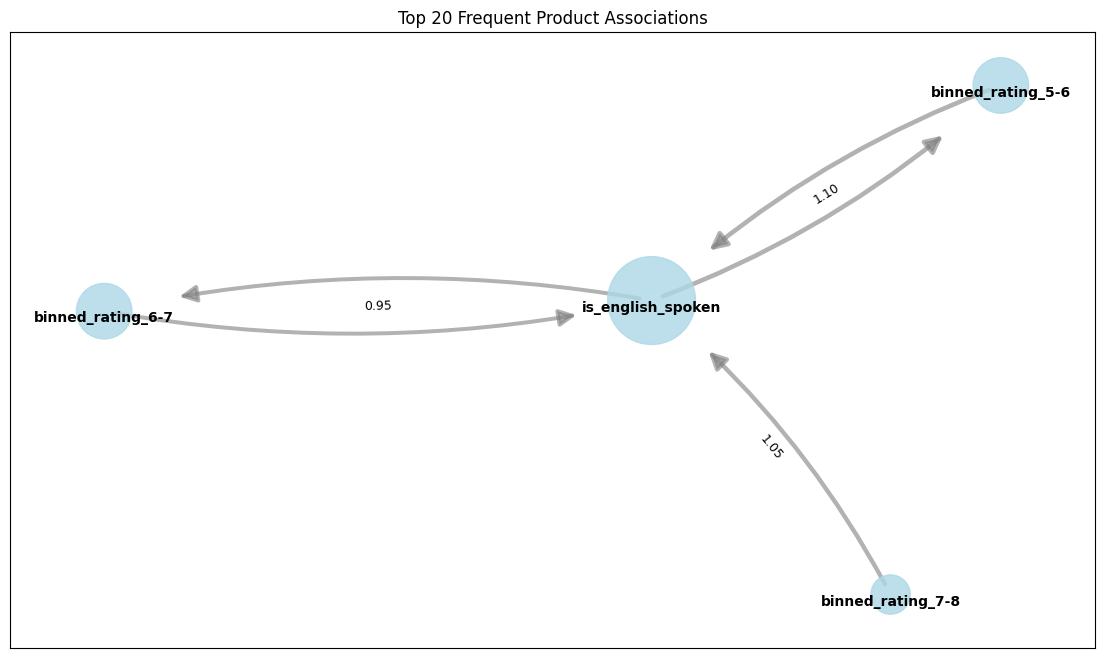

In [764]:
plot_association_graph(rules4, min_confidence=0.2, min_lift=0.9)

### 🤔 Is English Language Connected to Rating?

We examined whether English-speaking movies tend to perform better or worse in terms of audience ratings.

### 🔎 Key Observations:

1. **Rating 5–6 → English Spoken**  
   - Confidence: 91%  
   - Lift: 1.10  
   ✅ Movies rated in the 5–6 range are **very likely** to be in English. However, this reflects how dominant English is overall in the dataset.

2. **English Spoken → Rating 6–7**  
   - Confidence: 59.9%  
   - Lift: 0.95  
   ⚠️ Despite 6–7 being the most common rating bin, English-speaking movies are **slightly less likely** than random to fall into it.

3. **Rating 7–8 → English Spoken**  
   - Confidence: 87%  
   - Lift: 1.05  
   ✅ English-speaking movies are **mildly more likely** to score well (7–8) compared to others.

### 🎯 Conclusion:

While most English-speaking movies fall within the mid-range of ratings (5–7), they show **no strong correlation with high ratings overall**.  
There's only a **slight positive association** with very good ratings (7–8), and a **slight negative association** with average ones (6–7).
___

## Functions:

In [765]:
#✨
# 1. Filter Stronger Rules:
#    - Only include rules with high confidence and lift to reduce visual noise.
# 2. Dynamic Node & Edge Scaling:
#    - Scale node sizes based on support and edge widths based on lift.
# 3. Improved Label Placement:
#    - Rotate, reposition, or offset labels to avoid overlap and improve clarity.
# 4. Force-Directed Layout:
#    - Use a force-directed graph layout to naturally spread out nodes and reveal structure.

def plot_association_graph(rules, min_confidence=0.8, min_lift=1.1, max_rules=20):
    # Filter rules based on confidence & lift
    filtered_rules = rules[(rules["confidence"] >= min_confidence) & (rules["lift"] >= min_lift)]
    
    # ✅ Check if there are any rules left
    if filtered_rules.empty:
        print(f"No strong rules meet min_confidence={min_confidence} and min_lift={min_lift}. Try lowering thresholds.")
        return
    
    # ✅ Limit number of rules to max_rules
    filtered_rules = filtered_rules.sort_values(by=["confidence", "lift"], ascending=False).head(max_rules)
    
    # Create a directed graph
    G = nx.DiGraph()
    
    for _, row in filtered_rules.iterrows():
        antecedents = ", ".join(list(row["antecedents"]))
        consequents = ", ".join(list(row["consequents"]))
        G.add_edge(antecedents, consequents, weight=row["lift"])

    # Define graph layout (force-directed for better spacing)
    plt.figure(figsize=(14, 8))
    pos = nx.spring_layout(G, seed=42, k=0.8)  # k increases spacing

    # Node sizes based on support
    node_sizes = [G.degree(n) * 800 for n in G.nodes()]  

    # Edge widths based on lift
    edges = G.edges(data=True)
    edge_widths = [d['weight'] * 3 for _, _, d in edges]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=node_sizes, alpha=0.8)

    # Draw edges with larger arrowheads
    nx.draw_networkx_edges(
        G, pos, edgelist=edges,
        width=edge_widths,
        alpha=0.6,
        edge_color='gray',
        arrows=True,
        arrowsize=25,
        connectionstyle="arc3,rad=0.1",  # optional: gives a little curve
        min_target_margin=55  # 👈 adds spacing before the node
    )

    # Draw labels with rotation
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', verticalalignment='top')

    # Draw edge labels (Lift values)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

    plt.title(f"Top {max_rules} Frequent Product Associations")
    plt.show()

In [766]:
def recommend_genres(watched_items, rules, top_n=2):
    recommendations = []
    seen_recommendations = set()  # To track unique recommendations
    
    for _, row in rules.iterrows():
        antecedents = row['antecedents']
        consequents = row['consequents']
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']
        
        # If the antecedents (watched items) match the rule, recommend the consequents
        if antecedents.issubset(watched_items):
            recommended_items = list(consequents - watched_items)  # Exclude already watched items
            for item in recommended_items:
                if item not in seen_recommendations:  # Prevent duplicate recommendations
                    seen_recommendations.add(item)
                    recommendations.append((item, support, confidence, lift))
    
    # Sort recommendations by confidence and lift (stronger rules first)
    recommendations.sort(key=lambda x: (x[2], x[3]), reverse=True)  # Sort by confidence & lift
    
    # Select the top_n recommendations
    best_recommendations = recommendations[:top_n]
    
    # Format the explanation
    formatted_recommendations = []
    for rec in best_recommendations:
        item, support, confidence, lift = rec
        explanation = (
            f"If you watched {watched_items} I recommend you also watch: {item}.\n"
            f"Supported by metrics: Support: {support:.2f} | Confidence: {confidence:.2f} | Lift: {lift:.2f}."
        )
        formatted_recommendations.append(explanation)
    
    return formatted_recommendations

# Example Usage:
watched_genres = {"Romance"}  # Assume the customer watched these
recommendations = recommend_genres(watched_genres, rules1)

# Display Recommendations
for rec in recommendations:
    print(rec)

If you watched {'Romance'} I recommend you also watch: Drama.
Supported by metrics: Support: 0.13 | Confidence: 0.64 | Lift: 1.32.
If you watched {'Romance'} I recommend you also watch: Comedy.
Supported by metrics: Support: 0.10 | Confidence: 0.52 | Lift: 1.39.
